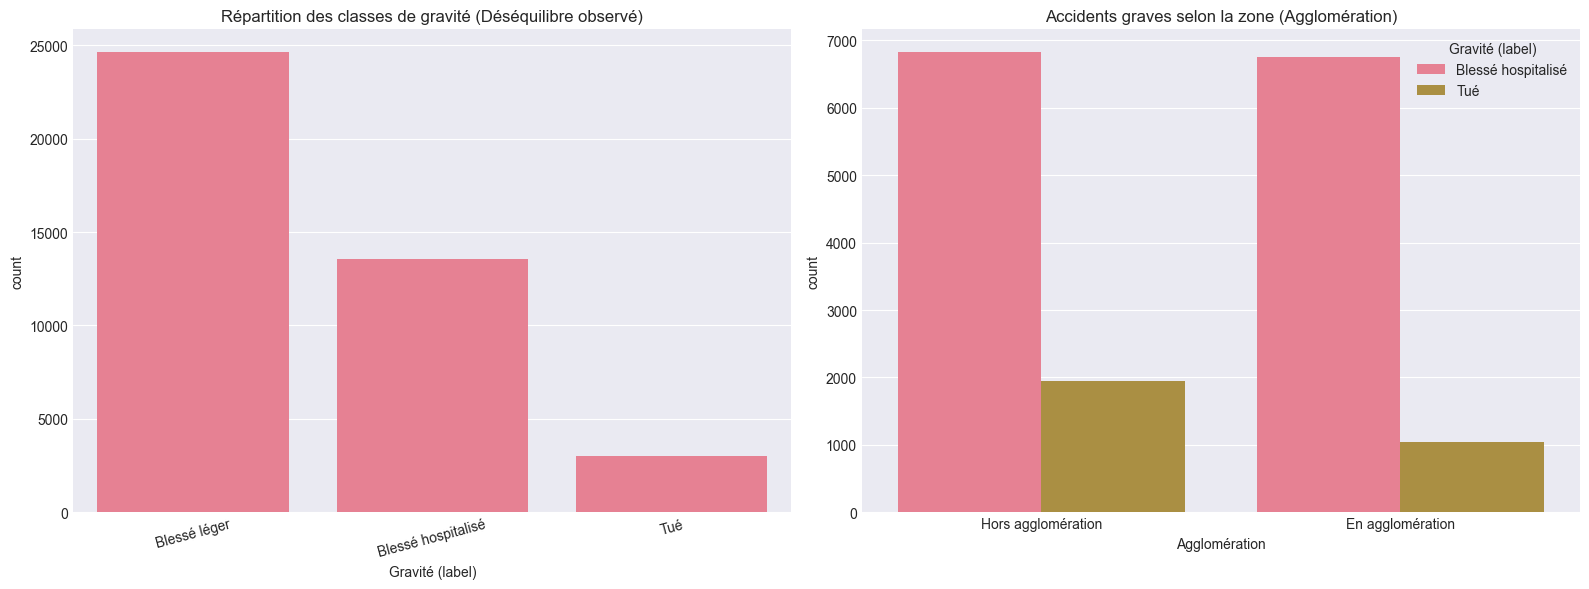

Les fichiers d'entraînement et de test ont été générés avec succès.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

# Désactivation des warnings pour un affichage propre dans le notebook
warnings.filterwarnings('ignore')
# Configuration visuelle pour les graphiques exploratoires
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ------------------------------------------------------------------------------
# 1. Chargement des données
# ------------------------------------------------------------------------------
# Lecture du fichier fourni dans le sujet
df = pd.read_csv('../data/accidents_2024.csv', sep=';', encoding='latin-1')

# ------------------------------------------------------------------------------
# 2. Nettoyage de base
# ------------------------------------------------------------------------------
# Suppression des lignes dupliquées
df.drop_duplicates(inplace=True)

# Suppression des lignes sans étiquette de gravité (inutilisables pour l'apprentissage)
df.dropna(subset=['Gravité (label)'], inplace=True)

# Harmonisation de la variable cible : correction d'une erreur de saisie identifiée ('O' majuscule)
df['Gravité (label)'] = df['Gravité (label)'].replace({'O': '0_Indemne', '0': '0_Indemne'})

# Traitement des valeurs manquantes : remplacement par la valeur la plus fréquente (mode)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# ------------------------------------------------------------------------------
# 3. Analyse Exploratoire (Vérification de la distribution)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Affichage de la répartition de la gravité (Mise en évidence du déséquilibre des classes)
sns.countplot(data=df, x='Gravité (label)', ax=axes[0], order=df['Gravité (label)'].value_counts().index)
axes[0].set_title("Répartition des classes de gravité (Déséquilibre observé)")
axes[0].tick_params(axis='x', rotation=15)

# Analyse d'une variable contextuelle (Agglomération) ciblée sur les accidents graves
df_graves = df[df['Gravité (label)'].isin(['Tué', 'Blessé hospitalisé'])]
sns.countplot(data=df_graves, x='Agglomération', hue='Gravité (label)', ax=axes[1])
axes[1].set_title("Accidents graves selon la zone (Agglomération)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. Feature Engineering et Encodage
# ------------------------------------------------------------------------------
# Séparation de la cible (Y) et des caractéristiques (X)
y_raw = df['Gravité (label)']

# Suppression des variables non prédictives (Identifiant unique et localisation trop granulaire)
X_raw = df.drop(columns=['Num_Acc', 'Gravité (label)', 'Département'])

# Encodage One-Hot des variables catégorielles 
# (Évite d'induire un ordre mathématique factice entre les catégories comme la météo)
colonnes_categorielles = X_raw.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X_raw, columns=colonnes_categorielles, drop_first=True)

# ------------------------------------------------------------------------------
# 5. Découpage du dataset (Train/Test Split) et Export
# ------------------------------------------------------------------------------
# - random_state fixe : garantit que chaque membre du groupe modélisera sur les mêmes données.
# - stratify : maintient la même proportion de chaque classe (ex: les Tués) dans le train et le test.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_raw, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_raw 
)

# Sauvegarde des jeux de données finaux pour l'entraînement individuel de nos algorithmes
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("Les fichiers d'entraînement et de test ont été générés avec succès.")